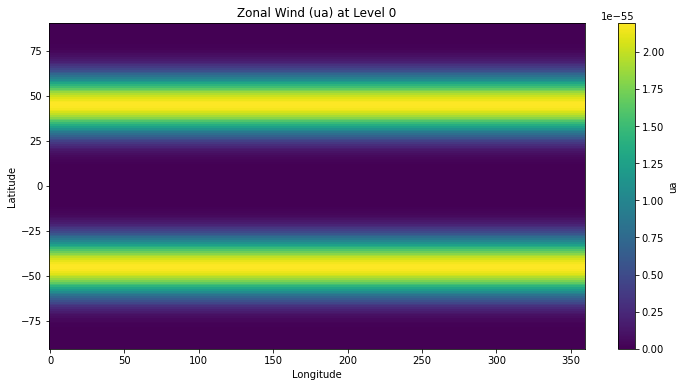

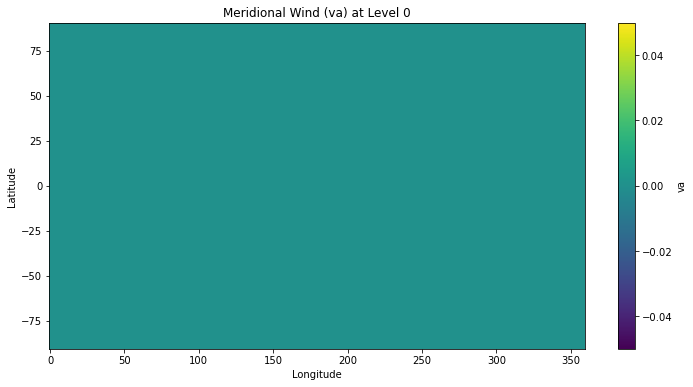

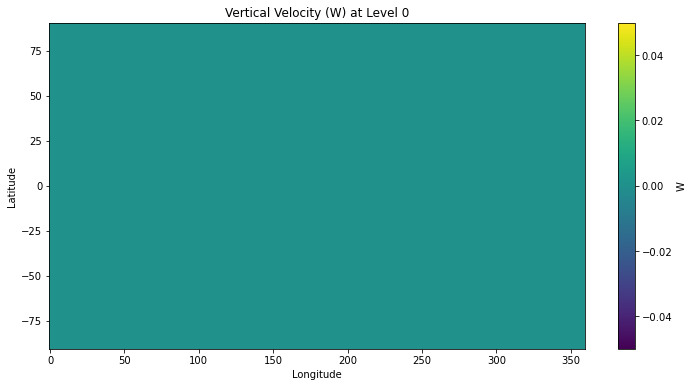

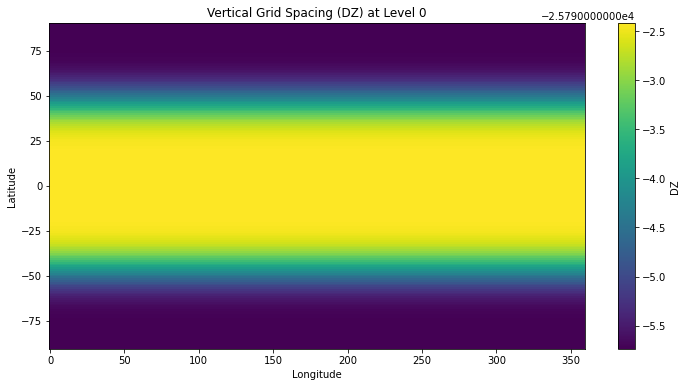

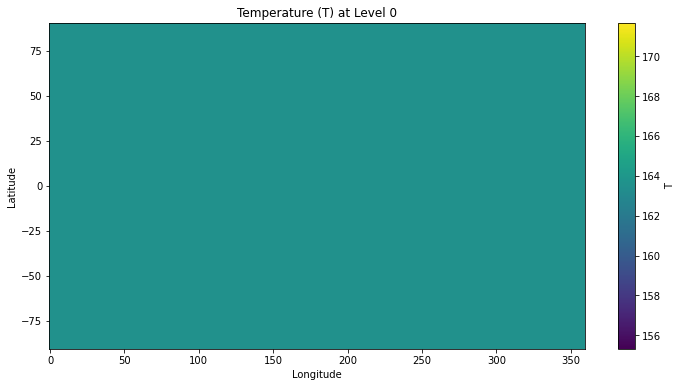

interactive(children=(Dropdown(description='Variable:', options=('ua', 'va', 'W', 'DZ', 'T'), value='ua'), Int…

<function __main__.interactive_plot(var_name, level)>

In [1]:
# **1. 导入必要的库**
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
%matplotlib inline

from ipywidgets import interact, IntSlider, Dropdown

from base_state import basic_state_generator

# **2. 初始化基本状态生成器**
base_state_gen = basic_state_generator()

# **3. 定义变量生成和转换函数**

def generate_variable(var_name, base_state_gen):
    """
    生成指定的变量数据。
    
    参数:
    - var_name: str, 变量名称。
    - base_state_gen: basic_state_generator 的实例。
    
    返回:
    - data: numpy 数组，生成的变量数据。
    - title: str, 绘图标题。
    """
    if var_name == 'ua':
        data = base_state_gen.generate_zonal_u()
        title = 'Zonal Wind (ua)'
    elif var_name == 'va':
        data = base_state_gen.generate_meridional_v()
        title = 'Meridional Wind (va)'
    elif var_name == 'W':
        data = base_state_gen.generate_vertical_w()
        title = 'Vertical Velocity (W)'
    elif var_name == 'DZ':
        data = base_state_gen.generate_DZ()
        title = 'Vertical Grid Spacing (DZ)'
    elif var_name == 'T':
        data = base_state_gen.generate_T_v()
        title = 'Temperature (T)'
    elif var_name == 'phis':
        data = base_state_gen.generate_phis()
        title = 'Surface Geopotential Height (phis)'
    else:
        raise ValueError(f"Variable '{var_name}' 未被识别。")
    
    return data, title

def convert_to_dataarray(data, var_name):
    """
    将 numpy 数组转换为 xarray DataArray 并设置坐标。
    
    参数:
    - data: numpy 数组，待转换的数据，形状为 (1, 32, 180, 360)。
    - var_name: str, 变量名称。
    
    返回:
    - dataarray: xarray.DataArray，转换后的数据数组。
    """
    # 假设数据形状为 (time, level, lat, lon)
    time = ['initial']  # 单个时间步
    level = np.arange(data.shape[1])  # 32 个垂直层级
    lat = np.linspace(-90, 90, data.shape[2])  # 180 个纬度点
    lon = np.linspace(0, 360, data.shape[3], endpoint=False)  # 360 个经度点
    
    coords = {
        'time': time,
        'level': level,
        'lat': lat,
        'lon': lon
    }
    
    dims = ['time', 'level', 'lat', 'lon']
    
    dataarray = xr.DataArray(
        data,
        coords=coords,
        dims=dims,
        name=var_name
    )
    
    return dataarray

def plot_variable(dataarray, title, level=0):
    """
    绘制指定层级的变量数据。
    
    参数:
    - dataarray: xarray.DataArray，待绘制的数据。
    - title: str，图表标题。
    - level: int，选择的垂直层级。
    """
    plt.figure(figsize=(12, 6))
    
    # 选择指定层级的数据
    data_level = dataarray.isel(level=level).squeeze('time')
    
    # 绘制数据
    data_level.plot(cmap='viridis')
    plt.title(f"{title} at Level {level}")
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.show()

# **4. 生成并可视化变量**

# 定义要处理的变量列表
variables = ['ua', 'va', 'W', 'DZ', 'T']

# 选择要绘制的层级
level_to_plot = 0  # 可以更改为 0 到 31 之间的整数

for var in variables:
    # 生成变量数据
    data, title = generate_variable(var, base_state_gen)
    
    # 转换为 DataArray
    dataarray = convert_to_dataarray(data, var)
    
    # 绘制变量
    plot_variable(dataarray, title, level=level_to_plot)

# **5. 添加交互式可视化**

def interactive_plot(var_name, level):
    """
    交互式绘图函数。
    
    参数:
    - var_name: str，选择的变量名称。
    - level: int，选择的垂直层级。
    """
    # 生成变量数据
    data, title = generate_variable(var_name, base_state_gen)
    
    # 转换为 DataArray
    dataarray = convert_to_dataarray(data, var_name)
    
    # 绘制变量
    plot_variable(dataarray, title, level)

# 定义每个变量的最大层级
max_levels = 31  # 32 个层级，从 0 到 31

# 创建交互式小部件
interact(
    interactive_plot,
    var_name=Dropdown(options=variables, description='Variable:'),
    level=IntSlider(min=0, max=max_levels, step=1, value=0, description='Level:')
)


[0.0027     0.00683128 0.01236086 0.01939672 0.02819855 0.03943121
 0.05381494 0.07198385 0.09453093 0.12208442 0.15522788 0.19455386
 0.24057391 0.29373042 0.35408178 0.42061733 0.49047655 0.55953775
 0.62429457 0.68294712 0.73498272 0.78048475 0.81978819 0.85339839
 0.88191495 0.90595159 0.92609257 0.94290581 0.9568761  0.96846543
 0.97799834 0.98566667]


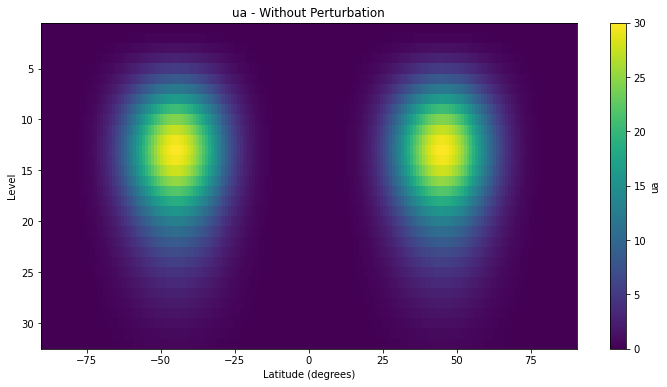

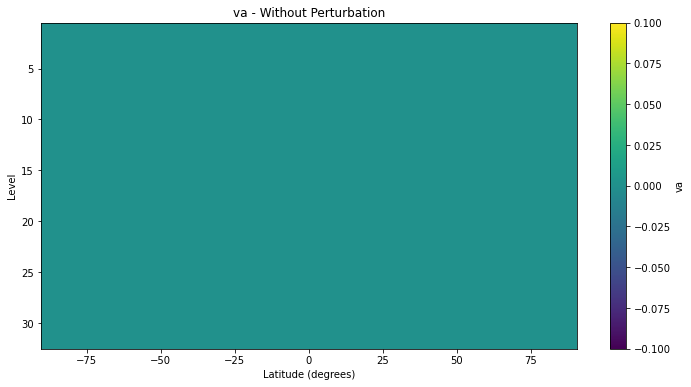

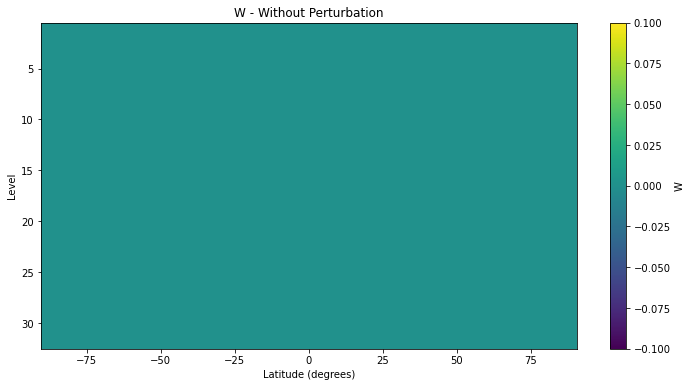

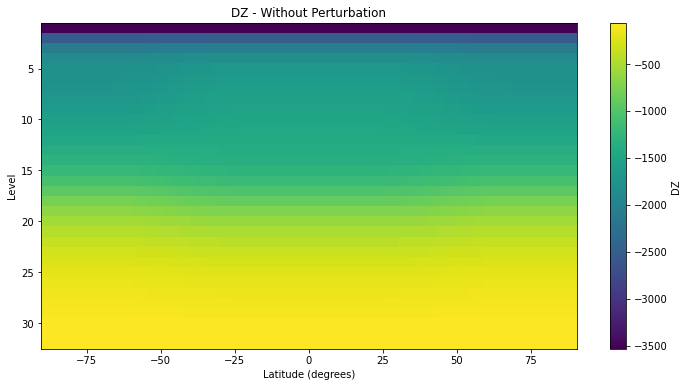

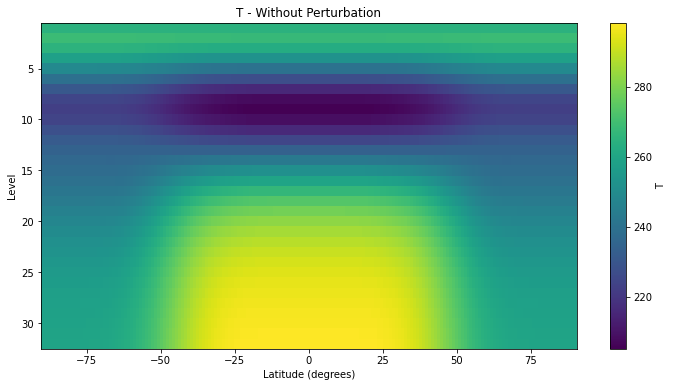

In [1]:
# 导入必要的库
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
%matplotlib inline

from ipywidgets import interact, IntSlider, Dropdown
from base_state import basic_state_generator


# 初始化基本状态生成器，不添加扰动
base_state_gen = basic_state_generator()


def generate_variables(base_state_gen, IsPerturbation=False):
    """
    使用 basic_state_generator 生成指定的变量。
    
    参数:
    - base_state_gen: basic_state_generator 的实例。
    - IsPerturbation: bool, 是否在 'ua' 中添加扰动。
    
    返回:
    - variables: dict, 键为变量名，值为 numpy 数组，形状为 (1, 32, 180, 360)。
    """
    variables = {}
    variables['ua'] = base_state_gen.generate_zonal_u(IsPerturbation=IsPerturbation)
    variables['va'] = base_state_gen.generate_meridional_v()
    variables['W'] = base_state_gen.generate_vertical_w()
    variables['DZ'] = base_state_gen.generate_DZ()
    variables['T'] = base_state_gen.generate_T_v()
    # 'phis' 被排除在外
    return variables

def convert_to_dataarray(data, var_name):
    """
    将 numpy 数组转换为 xarray DataArray，并对经度进行平均。
    
    参数:
    - data: numpy 数组，形状为 (1, 32, 180, 360)。
    - var_name: str, 变量名称。
    
    返回:
    - dataarray: xarray.DataArray，形状为 (32, 180)，坐标为 (level, lat)。
    """
    # 对经度轴进行平均，得到形状 (1, 32, 180)
    data_avg_lon = np.mean(data, axis=-1)  # shape (1, 32, 180)
    data_avg_lon = data_avg_lon.squeeze(axis=0)  # shape (32, 180)
    
    # 定义坐标
    level = np.arange(1, 33)  # 32 个层级，1 到 32
    lat = np.linspace(-90, 90, 180)  # 180 个纬度点
    
    coords = {
        'level': level,
        'lat': lat
    }
    
    dims = ['level', 'lat']
    
    dataarray = xr.DataArray(
        data_avg_lon,
        coords=coords,
        dims=dims,
        name=var_name
    )
    
    return dataarray

def plot_variable(dataarray, title, level=None):
    """
    绘制变量数据的热图，横轴为纬度，纵轴为层级。
    
    参数:
    - dataarray: xarray.DataArray，形状为 (level, lat)。
    - title: str，图表标题。
    - level: int, 可选，若指定则只绘制该层级的数据。
    """
    plt.figure(figsize=(12, 6))
    
    if level is not None:
        # 绘制单个层级的数据
        data_to_plot = dataarray.isel(level=level).squeeze()
        plt.plot(dataarray.lat, data_to_plot, label=title)
        plt.xlabel('Latitude (degrees)')
        plt.ylabel(f'{title}')
        plt.title(f"{title} at Level {level + 1}")
        plt.legend()
        plt.grid(True)
    else:
        # 绘制全部层级的数据作为热图
        # 使用 pcolormesh 绘制热图，不传递 'aspect' 参数
        plt.pcolormesh(dataarray.lat, dataarray.level, dataarray, cmap='viridis', shading='auto')
        plt.title(title)
        plt.xlabel('Latitude (degrees)')
        plt.ylabel('Level')
        plt.gca().invert_yaxis()  # 可选：将层级1显示在顶部
        cbar = plt.colorbar(label=var_name)
    
    plt.show()


# 不添加扰动，确保变量与经度无关
variables = generate_variables(base_state_gen, IsPerturbation=False)

# 定义要可视化的变量列表（排除 'phis'）
variables_to_plot = ['ua', 'va', 'W', 'DZ', 'T']

# 选择要绘制的层级范围
# 如果需要交互式选择层级，请跳至下方交互式可视化部分
level_to_plot = None  # 设置为具体层级（0 到 31）时，只绘制该层级的数据

for var_name in variables_to_plot:
    data = variables[var_name]
    dataarray = convert_to_dataarray(data, var_name)
    title = f"{var_name} - Without Perturbation"
    plot_variable(dataarray, title, level=level_to_plot)


